In [ ]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ROUND = 150
TASK_WHITELIST = ["semseg", "normal", "edge", "depth", "saliency"]   # or ["semseg", "normal"] or None
PERTASK_COLS   = ["testMetric", "testMetricGlobal"]
OVERALL_COLS   = ["testMetricGlobal"]
SERVER_COLS    = ["meanDeltaNorm", "meanClientDeltaNorm", "meanDistToMean", "meanCosine", "fracNegativeCosine"]

# ROOT = Path("../results/label_skew/low")
# FILES = {
#     "none": "label_skew_low_none.json",
#     "fedavg": "label_skew_low_fedavg.json",
#     "fedhca2": "label_skew_low_fedhca2.json",
# }

ROOT = Path("../results/label_skew/med")
FILES = {
    "none": "label_skew_med_none.json",
    "fedavg": "label_skew_med_fedavg.json",
    "fedhca2": "label_skew_med_fedhca2.json",
}

# ROOT = Path("../results/label_skew/high")
# FILES = {
#     "none": "label_skew_high_none.json",
#     "fedavg": "label_skew_high_fedavg.json",
#     "fedhca2": "label_skew_high_fedhca2.json",
# }

# ROOT = Path("../results/quantity_skew/low")
# FILES = {
#     "none": "quantity_skew_low_none.json",
#     "fedavg": "quantity_skew_low_fedavg.json",
#     "fedhca2": "quantity_skew_low_fedhca2.json",
# }

# ROOT = Path("../results/quantity_skew/med")
# FILES = {
#     "none": "quantity_skew_med_none.json",
#     "fedavg": "quantity_skew_med_fedavg.json",
#     "fedhca2": "quantity_skew_med_fedhca2.json",
# }

# ROOT = Path("../results/quantity_skew/high")
# FILES = {
#     "none": "quantity_skew_high_none.json",
#     "fedavg": "quantity_skew_high_fedavg.json",
#     "fedhca2": "quantity_skew_high_fedhca2.json",
# }

# ROOT = Path("../results/type_overlap/low")
# FILES = {
#     "none": "type_overlap_low_none.json",
#     "fedavg": "type_overlap_low_fedavg.json",
#     "fedhca2": "type_overlap_low_fedhca2.json",
# }

# ROOT = Path("../results/type_overlap/med")
# FILES = {
#     "none": "type_overlap_med_none.json",
#     "fedavg": "type_overlap_med_fedavg.json",
#     "fedhca2": "type_overlap_med_fedhca2.json",
# }

# ROOT = Path("../results/type_overlap/high")
# FILES = {
#     "none": "type_overlap_high_none.json",
#     "fedavg": "type_overlap_high_fedavg.json",
#     "fedhca2": "type_overlap_high_fedhca2.json",
# }

# ROOT = Path("../results/count_imbalance/low")
# FILES = {
#     "none": "count_imbalance_low_none.json",
#     "fedavg": "count_imbalance_low_fedavg.json",
#     "fedhca2": "count_imbalance_low_fedhca2.json",
# }

# ROOT = Path("../results/count_imbalance/med")
# FILES = {
#     "none": "count_imbalance_med_none.json",
#     "fedavg": "count_imbalance_med_fedavg.json",
#     "fedhca2": "count_imbalance_med_fedhca2.json",
# }

# ROOT = Path("../results/count_imbalance/high")
# FILES = {
#     "none": "count_imbalance_high_none.json",
#     "fedavg": "count_imbalance_high_fedavg.json",
#     "fedhca2": "count_imbalance_high_fedhca2.json",
# }

# ROOT = Path("../results/epochs_per_client/1")
# FILES = {
#     "none": "epochs_per_client_1_none.json",
#     "fedavg": "epochs_per_client_1_fedavg.json",
#     "fedhca2": "epochs_per_client_1_fedhca2.json",
# }

# ROOT = Path("../results/epochs_per_client/3")
# FILES = {
#     "none": "epochs_per_client_3_none.json",
#     "fedavg": "epochs_per_client_3_fedavg.json",
#     "fedhca2": "epochs_per_client_3_fedhca2.json",
# }

def get_round_deltaM(round_obj):
    # plot directly; expects scalar numeric
    dm = None
    if isinstance(round_obj, dict):
        if round_obj.get("deltaM") is not None:
            dm = round_obj.get("deltaM")
        elif isinstance(round_obj.get("serverMetrics"), dict) and round_obj["serverMetrics"].get("deltaM") is not None:
            dm = round_obj["serverMetrics"].get("deltaM")

    return float(dm) if isinstance(dm, (int, float)) else None


def build_id_to_index_map(data):
    """
    Prefer header.clients order.
    Fallback: infer from first round's clientMetrics order.
    """
    header_clients = (data.get("header", {}) or {}).get("clients", []) or []
    if header_clients:
        return {c.get("id"): i for i, c in enumerate(header_clients) if c.get("id") is not None}

    rounds = data.get("rounds", []) or []
    if rounds and (rounds[0].get("clientMetrics") is not None):
        cms = rounds[0].get("clientMetrics") or []
        return {cm.get("id"): i for i, cm in enumerate(cms) if cm.get("id") is not None}

    return {}


def parse_file(fp, algo_name):
    with open(fp, "r") as f:
        data = json.load(f)

    id2idx = build_id_to_index_map(data)

    rows_client, rows_task, rows_server, rows_delta = [], [], [], []

    for r in data.get("rounds", []) or []:
        rnd = r.get("round")

        # server metrics
        sm = r.get("serverMetrics") or {}
        rows_server.append({"algo": algo_name, "round": rnd, **sm})

        # deltaM (scalar)
        rows_delta.append({"algo": algo_name, "round": rnd, "deltaM": get_round_deltaM(r)})

        # per-client metrics
        cms = r.get("clientMetrics", []) or []
        for j, cm in enumerate(cms):
            cid = cm.get("id")
            # Prefer header-based index; fallback to order in this round if unknown
            cidx = id2idx.get(cid, j)

            rows_client.append({
                "algo": algo_name,
                "round": rnd,
                "client_idx": cidx,
                "client_id_raw": cid,   # kept for debugging only
                "epoch": cm.get("epoch"),
                "lossTrain": cm.get("lossTrain"),
                "lossTest": cm.get("lossTest"),
                "lossTestGlobal": cm.get("lossTestGlobal"),
            })

            for head in cm.get("perHead", []) or []:
                rows_task.append({
                    "algo": algo_name,
                    "round": rnd,
                    "client_idx": cidx,
                    "client_id_raw": cid,
                    "task": head.get("task"),
                    "trainLoss": head.get("trainLoss"),
                    "testLoss": head.get("testLoss"),
                    "testLossGlobal": head.get("testLossGlobal"),
                    "trainMetric": head.get("trainMetric"),
                    "testMetric": head.get("testMetric"),
                    "testMetricGlobal": head.get("testMetricGlobal"),
                })

    df_client = pd.DataFrame(rows_client).sort_values(["algo", "round", "client_idx"])
    df_task   = pd.DataFrame(rows_task).sort_values(["algo", "round", "client_idx", "task"])
    df_server = pd.DataFrame(rows_server).sort_values(["algo", "round"])
    df_delta  = pd.DataFrame(rows_delta).sort_values(["algo", "round"])

    return df_client, df_task, df_server, df_delta, data


all_client, all_task, all_server, all_delta = [], [], [], []
raw = {}

for algo, fp in FILES.items():
    p = Path(ROOT, fp)
    if not p.exists():
        raise FileNotFoundError(f"Missing: {fp}")
    dc, dt, ds, dd, data = parse_file(str(p), algo)
    all_client.append(dc); all_task.append(dt); all_server.append(ds); all_delta.append(dd)
    raw[algo] = data

df_client = pd.concat(all_client, ignore_index=True)
df_task   = pd.concat(all_task, ignore_index=True)
df_server = pd.concat(all_server, ignore_index=True)
df_delta  = pd.concat(all_delta, ignore_index=True)

if ROUND is not None:
    df_client = df_client[df_client["round"] <= ROUND]
    df_task   = df_task[df_task["round"] <= ROUND]
    df_server = df_server[df_server["round"] <= ROUND]
    df_delta  = df_delta[df_delta["round"] <= ROUND]

C:\Users\ern yon\AppData\Local\Temp\ipykernel_18636\2290664378.py:213: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_delta  = pd.concat(all_delta, ignore_index=True)


In [63]:
# how many clients per algo? (from header if present; fallback to max observed index+1)
def num_clients_for_algo(algo):
    hdr = (raw[algo].get("header", {}) or {}).get("clients", []) or []
    if hdr:
        return len(hdr)
    # fallback from parsed data
    sub = df_client[df_client["algo"] == algo]
    return int(sub["client_idx"].max() + 1) if not sub.empty else 0

n_clients = {algo: num_clients_for_algo(algo) for algo in FILES}
n_common = min(n_clients.values())
common_client_indices = list(range(n_common))

n_clients, common_client_indices

({'none': 3, 'fedavg': 3, 'fedhca2': 3}, [0, 1, 2])

In [64]:
def plot_for_client_idx(df, y, client_idx, title):
    sub = df[df["client_idx"] == client_idx]
    if sub.empty or y not in sub.columns:
        return

    plt.figure()
    for algo, g in sub.groupby("algo"):
        g = g.sort_values("round")
        plt.plot(g["round"], g[y], label=algo)
    plt.xlabel("round")
    plt.ylabel(y)
    plt.title(f"{title} — client_idx={client_idx}")
    plt.legend()
    plt.show()


def plot_for_client_task(df_task, task, y, client_idx, title):
    sub = df_task[(df_task["client_idx"] == client_idx) & (df_task["task"] == task)]
    if sub.empty or y not in sub.columns:
        return

    plt.figure()
    for algo, g in sub.groupby("algo"):
        g = g.sort_values("round")
        plt.plot(g["round"], g[y], label=algo)
    plt.xlabel("round")
    plt.ylabel(y)
    plt.title(f"{title} — client_idx={client_idx}, task={task}")
    plt.legend()
    plt.show()


def plot_server_metric(y, title):
    if y not in df_server.columns:
        return
    plt.figure()
    for algo, g in df_server.groupby("algo"):
        g = g.sort_values("round")
        plt.plot(g["round"], g[y], label=algo)
    plt.xlabel("round")
    plt.ylabel(y)
    plt.title(title)
    plt.legend()
    plt.show()


def plot_deltaM():
    plt.figure()
    for algo, g in df_delta.groupby("algo"):
        g = g.sort_values("round")
        plt.plot(g["round"], g["deltaM"], label=algo)
    plt.xlabel("round")
    plt.ylabel("deltaM")
    plt.title("deltaM over rounds (direct from JSON)")
    plt.legend()
    plt.show()

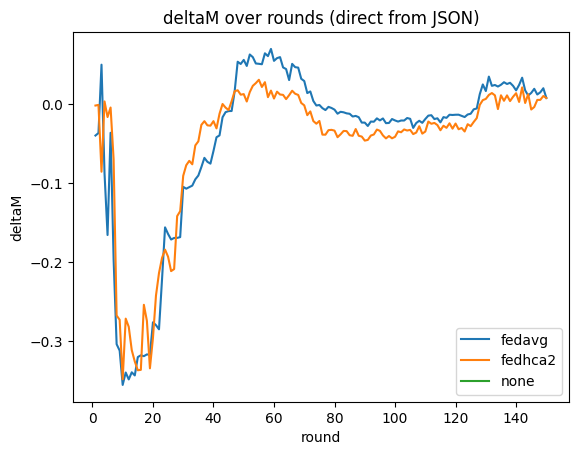

In [65]:
plot_deltaM()

In [66]:
# # ---- normalize whitelist ----
# def normalize_task_whitelist(wl):
#     if wl is None:
#         return None
#     if isinstance(wl, str):
#         items = [wl]
#     else:
#         items = list(wl)

#     out = []
#     for s in items:
#         if not isinstance(s, str):
#             continue
#         if "," in s:
#             out.extend([x.strip() for x in s.split(",") if x.strip()])
#         else:
#             out.append(s.strip())
#     return out or None

# TASK_WHITELIST = normalize_task_whitelist(TASK_WHITELIST)
# TASK_SET = set(TASK_WHITELIST) if TASK_WHITELIST else None

# # ---- helpers ----
# def plot_for_client_idx(df, y, client_idx, title):
#     sub = df[df["client_idx"] == client_idx]
#     if sub.empty or y not in sub.columns:
#         return
#     plt.figure()
#     for algo, g in sub.groupby("algo"):
#         g = g.sort_values("round")
#         plt.plot(g["round"], g[y], label=algo)
#     plt.xlabel("round"); plt.ylabel(y)
#     plt.title(f"{title} — Client {client_idx + 1}")
#     plt.legend(); plt.show()

# def plot_for_client_task(df_task, task, y, client_idx, title):
#     sub = df_task[(df_task["client_idx"] == client_idx) & (df_task["task"] == task)]
#     if sub.empty or y not in sub.columns:
#         return
#     plt.figure()
#     for algo, g in sub.groupby("algo"):
#         g = g.sort_values("round")
#         plt.plot(g["round"], g[y], label=algo)
#     plt.xlabel("round"); plt.ylabel(y)
#     plt.title(f"{title} — Client {client_idx + 1}, {task}")
#     plt.legend(); plt.show()

# def plot_server_metric(y, title):
#     if y not in df_server.columns:
#         return
#     plt.figure()
#     for algo, g in df_server.groupby("algo"):
#         g = g.sort_values("round")
#         plt.plot(g["round"], g[y], label=algo)
#     plt.xlabel("round"); plt.ylabel(y)
#     plt.title(title)
#     plt.legend(); plt.show()

# # ---- determine common client indices ----
# n_common = int(df_client.groupby("algo")["client_idx"].max().min() + 1)
# common_client_indices = list(range(n_common))

# # Optional: close old figures so you only see new ones
# plt.close("all")

# # ---- OVERALL ----
# for cidx in common_client_indices:
#     for col in OVERALL_COLS:
#         plot_for_client_idx(df_client, col, cidx, f"Overall: {col}")

# # ---- PER-TASK ----
# tasks = sorted(df_task["task"].dropna().unique().tolist())
# if TASK_SET is not None:
#     tasks = [t for t in tasks if t in TASK_SET]

# for cidx in common_client_indices:
#     for task in tasks:
#         for col in PERTASK_COLS:
#             plot_for_client_task(df_task, task, col, cidx, f"Per-task: {col}")

# # ---- SERVER ----
# for col in SERVER_COLS:
#     plot_server_metric(col, f"Server: {col} over rounds")

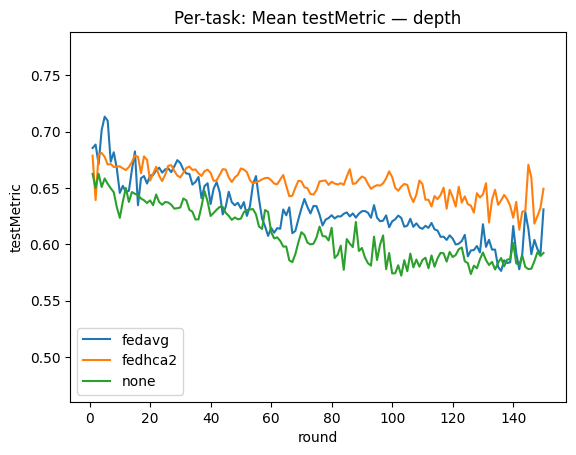

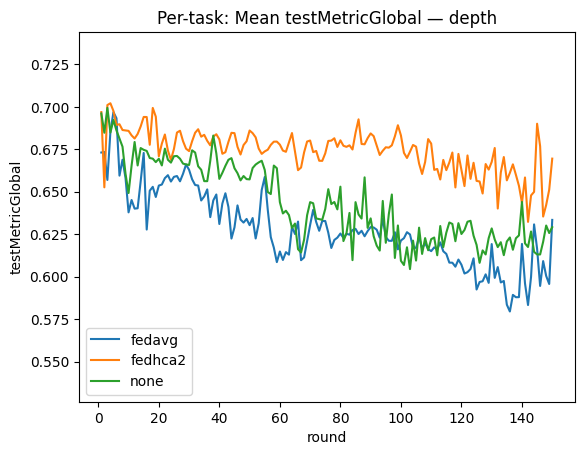

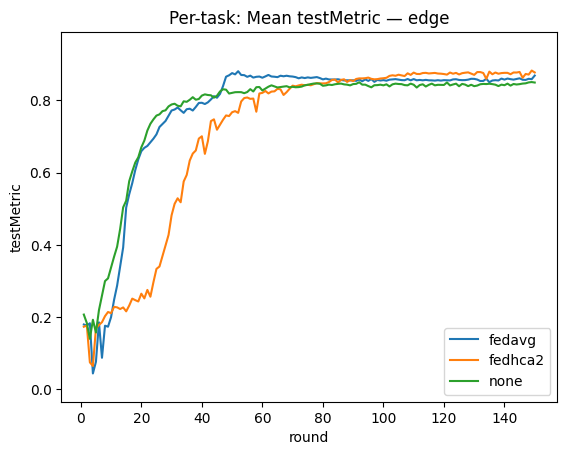

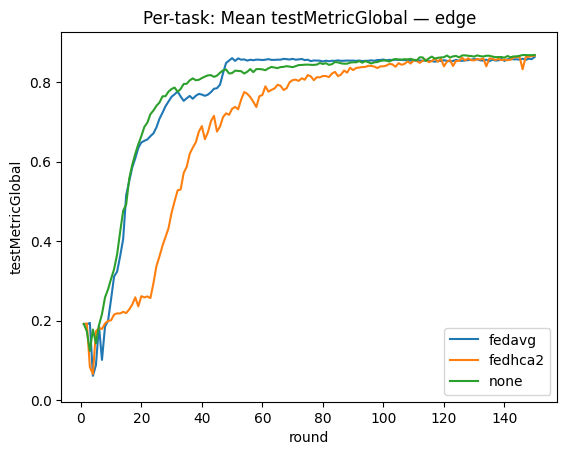

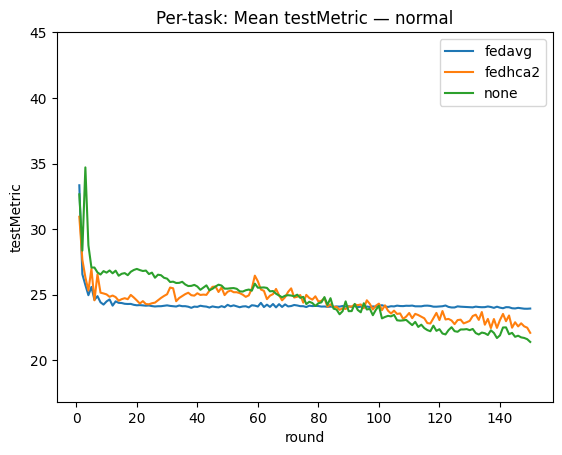

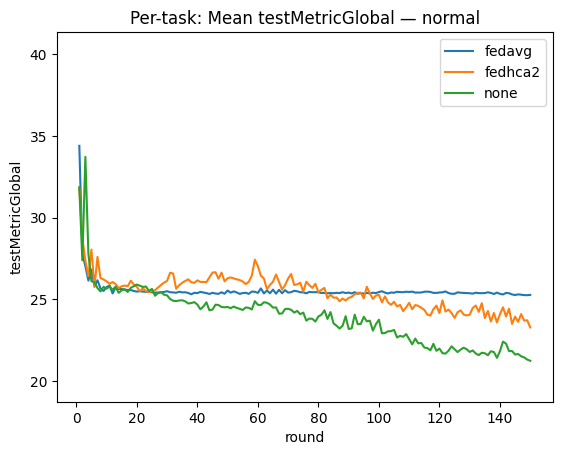

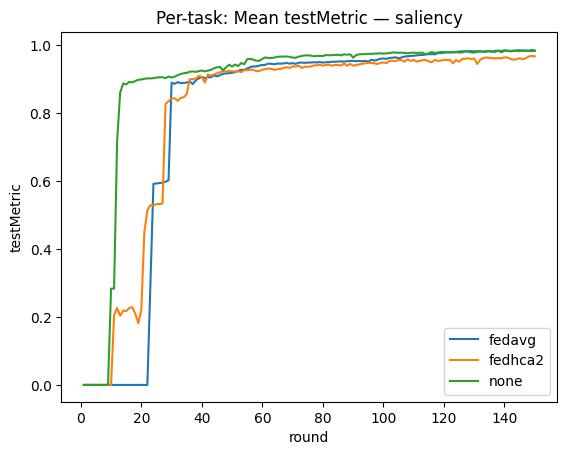

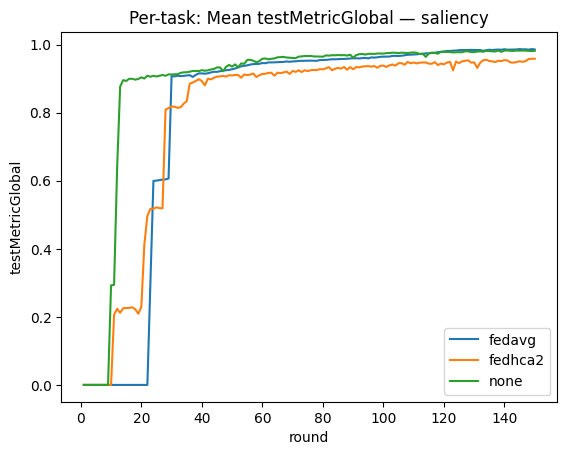

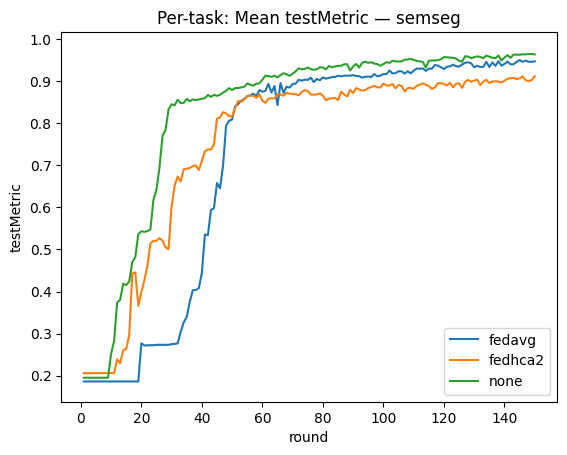

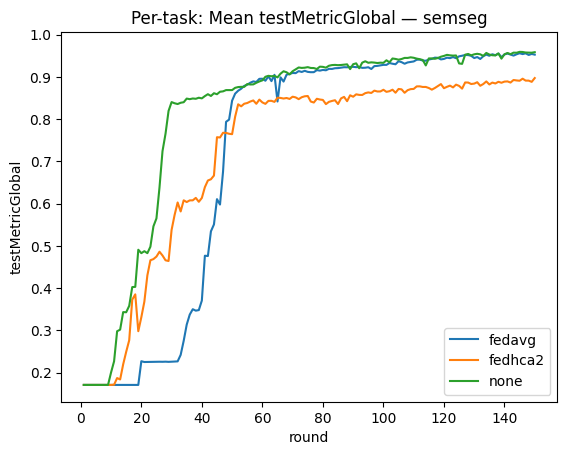

In [67]:
def plot_task_mean_minmax(df_task, task, y, title):
    sub = df_task[df_task["task"] == task]
    if sub.empty or y not in sub.columns:
        return

    plt.figure()
    for algo, g_algo in sub.groupby("algo"):
        agg = (g_algo.groupby("round")[y]
                     .agg(mean="mean", min="min", max="max")
                     .reset_index()
                     .sort_values("round"))
        plt.plot(agg["round"], agg["mean"], label=algo)
        plt.fill_between(agg["round"], agg["min"], agg["max"], alpha=0.0)

    plt.xlabel("round")
    plt.ylabel(y)
    plt.title(f"{title} — {task}")
    plt.legend()
    plt.show()

# Example:
tasks = sorted(df_task["task"].dropna().unique().tolist())

for task in tasks:
    for col in PERTASK_COLS:
        plot_task_mean_minmax(df_task, task, col, f"Per-task: Mean {col}")

In [68]:
def build_id_to_index_map(data):
    hdr_clients = (data.get("header", {}) or {}).get("clients", []) or []
    if hdr_clients:
        return {c.get("id"): i for i, c in enumerate(hdr_clients) if c.get("id") is not None}
    # fallback: first round order
    rounds = data.get("rounds", []) or []
    if rounds and rounds[0].get("clientMetrics"):
        cms = rounds[0]["clientMetrics"]
        return {cm.get("id"): i for i, cm in enumerate(cms) if cm.get("id") is not None}
    return {}

def parse_file(fp, algo):
    with open(fp, "r") as f:
        data = json.load(f)
    id2idx = build_id_to_index_map(data)

    rows_task = []
    rows_overall = []

    rounds = data.get("rounds", []) or []
    if not rounds:
        return pd.DataFrame(), pd.DataFrame()

    if ROUND is None:
        rmatch = max(rounds, key=lambda r: r.get("round", -1))
    else:
        target_round = ROUND #- 1   # convert epoch -> stored round
        rmatch = next((r for r in rounds if r.get("round") == target_round), None)
        if rmatch is None:
            raise ValueError(f"{algo}: epoch {ROUND} (round {target_round}) not found in {fp}")

    rnd = rmatch["round"]
    epoch = rnd + 1

    for j, cm in enumerate(rmatch.get("clientMetrics", []) or []):
        cid = cm.get("id")
        cidx = id2idx.get(cid, j)

        rows_overall.append({
            "algo": algo,
            "round": rnd,
            "epoch": epoch,
            "client_idx": cidx,
            "lossTestGlobal": cm.get("lossTestGlobal"),
            "lossTest": cm.get("lossTest"),
            "lossTrain": cm.get("lossTrain"),
        })

        for head in cm.get("perHead", []) or []:
            rows_task.append({
                "algo": algo,
                "round": rnd,
                "epoch": epoch,
                "client_idx": cidx,
                "task": head.get("task"),
                "testMetric": head.get("testMetric"),
                "testMetricGlobal": head.get("testMetricGlobal"),
            })

    return pd.DataFrame(rows_task), pd.DataFrame(rows_overall)

# load all
df_task_all = []
df_overall_all = []
for algo, fp in FILES.items():
    p = Path(ROOT, fp)
    if not p.exists():
        raise FileNotFoundError(fp)
    dt, do = parse_file(str(p), algo)
    df_task_all.append(dt)
    df_overall_all.append(do)

df_task = pd.concat(df_task_all, ignore_index=True)
df_overall = pd.concat(df_overall_all, ignore_index=True)

def mean_std_table(df, value_col, index_col="task"):
    """
    Returns a pivot table with cells like 'mean ± std' (std is sample std, ddof=1).
    """
    agg = (
        df.groupby(["algo", index_col])[value_col]
          .agg(mean="mean", std=lambda x: float(np.std(x, ddof=1)))
          .reset_index()
    )
    agg["mean±std"] = agg["mean"].map(lambda x: f"{x:.4f}") + " ± " + agg["std"].map(lambda x: f"{x:.4f}")
    out = agg.pivot(index=index_col, columns="algo", values="mean±std")
    return out

# per-task tables
tbl_local  = mean_std_table(df_task, "testMetric", index_col="task")
tbl_global = mean_std_table(df_task, "testMetricGlobal", index_col="task")

display(tbl_local)
display(tbl_global)

# optional overall table (lossTestGlobal)
tbl_overall = mean_std_table(df_overall, "lossTestGlobal", index_col="round")
display(tbl_overall)

algo,fedavg,fedhca2,none
task,,,
depth,0.6309 ± 0.0354,0.6492 ± 0.0926,0.5923 ± 0.1077
edge,0.8688 ± 0.0073,0.8775 ± 0.0475,0.8495 ± 0.0743
normal,23.9374 ± 1.0357,22.0844 ± 4.2396,21.3896 ± 1.8749
saliency,0.9847 ± 0.0006,0.9681 ± 0.0127,0.9839 ± 0.0053
semseg,0.9473 ± 0.0154,0.9119 ± 0.0294,0.9638 ± 0.0161


algo,fedavg,fedhca2,none
task,,,
depth,0.6335 ± 0.0111,0.6695 ± 0.0333,0.6292 ± 0.0632
edge,0.8637 ± 0.0019,0.8671 ± 0.0062,0.8687 ± 0.0113
normal,25.2714 ± 0.1147,23.2821 ± 1.7295,21.2377 ± 1.2233
saliency,0.9857 ± 0.0010,0.9585 ± 0.0102,0.9818 ± 0.0007
semseg,0.9524 ± 0.0011,0.8970 ± 0.0314,0.9583 ± 0.0078


algo,fedavg,fedhca2,none
round,,,
150,0.2937 ± 0.0010,0.3318 ± 0.0232,0.2503 ± 0.0194


In [69]:
import numpy as np
import pandas as pd

# ---- Task -> metric name ----
TASK_METRIC_MAP = {
    "semseg": "meanIoU",
    "edge": "odsF",
    "saliency": "f1",
    "depth": "rmse",
    "normal": "meanAngularErr",
}

LOWER_IS_BETTER = {
    "meanIoU": False,
    "odsF": False,
    "f1": False,
    "rmse": True,
    "meanAngularErr": True,
}

def per_task_summary(df_task: pd.DataFrame, metric_col: str) -> pd.DataFrame:
    """
    Returns rows: algo, round, task, mean, std, n
    where mean/std are across clients (for that algo/round/task).
    """
    g = (
        df_task.groupby(["algo", "round", "task"])[metric_col]
        .agg(mean="mean", std=lambda x: float(np.std(x, ddof=1)) if len(x) > 1 else 0.0, n="count")
        .reset_index()
        .sort_values(["algo", "round", "task"])
    )
    return g

summ_local  = per_task_summary(df_task, "testMetric")
summ_global = per_task_summary(df_task, "testMetricGlobal")

def deltaM_from_means(fed: dict, local: dict) -> float | None:
    tasks = [t for t in local.keys()
             if np.isfinite(local.get(t, np.nan)) and np.isfinite(fed.get(t, np.nan))]
    if not tasks:
        return None

    s = 0.0
    n = 0
    for t in tasks:
        m_local = float(local[t])
        m_fed   = float(fed[t])

        if not np.isfinite(m_local) or not np.isfinite(m_fed) or abs(m_local) < 1e-12:
            continue

        metric_name = TASK_METRIC_MAP.get(t)
        sign = -1.0 if LOWER_IS_BETTER.get(metric_name, False) else 1.0
        s += sign * ((m_fed - m_local) / m_local)
        n += 1

    return (s / n) if n > 0 else None


def compute_deltaM_series(summary_df: pd.DataFrame, local_algo: str = "none") -> pd.DataFrame:
    """
    summary_df: columns [algo, round, task, mean] where 'mean' is already averaged across clients.
    Returns one deltaM per (algo, round) against local_algo.
    """
    wide = summary_df.pivot_table(index=["algo", "round"], columns="task", values="mean", aggfunc="first")

    # baseline (local) means for each round
    local = wide.loc[local_algo]  # index=round, columns=task

    rows = []
    for (algo, rnd), row in wide.iterrows():
        if algo == local_algo:
            rows.append({"algo": algo, "round": rnd, "deltaM": 0.0})
            continue

        if rnd not in local.index:
            rows.append({"algo": algo, "round": rnd, "deltaM": None})
            continue

        fed_dict   = row.to_dict()
        local_dict = local.loc[rnd].to_dict()
        dm = deltaM_from_means(fed_dict, local_dict)
        rows.append({"algo": algo, "round": rnd, "deltaM": dm})

    return pd.DataFrame(rows).sort_values(["algo", "round"])


deltaM_local_series  = compute_deltaM_series(summ_local,  local_algo="none")
deltaM_global_series = compute_deltaM_series(summ_global, local_algo="none")

display(deltaM_local_series.head())
display(deltaM_global_series.head())

,algo,round,deltaM
0,fedavg,150,-0.035594
1,fedhca2,150,-0.033133
2,none,150,0.000000


,algo,round,deltaM
0,fedavg,150,-0.040944
1,fedhca2,150,-0.049997
2,none,150,0.000000
